# **Unsupervised Learning Project**

**Students**

Alexandre Santos nº72970

David Natal nº72997

Miguel Mestre nº73018

In [1]:
!pip install seaborn scipy scikit-fuzzy -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\david\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)

In [3]:
file_path = os.path.join("data", "hotel_bookings_course_release_v1.csv")

df = pd.read_csv(file_path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

# Checksum/Hash

In [5]:
import hashlib
import os

# A hash oficial que partilhaste
expected_hash = "7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06"

# Substitui pelo caminho correto do teu ficheiro
file_path = "data\\hotel_bookings_course_release_v1.csv" 

with open(file_path, "rb") as f:
    file_hash = hashlib.sha256(f.read()).hexdigest()

print(f"Calculated hash: {file_hash}")

if file_hash == expected_hash:
    print("Success")
else:
    print("File might be corrupted")

Calculated hash: 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06
Success


## EDA

In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

#### Average Daily Rate Distribuition

<Axes: xlabel='adr', ylabel='Count'>

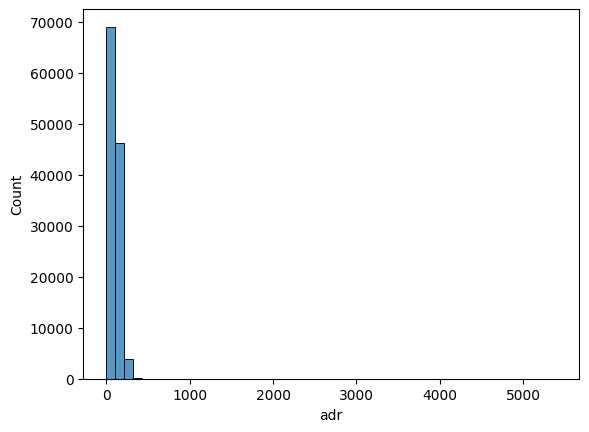

In [7]:
sns.histplot(df["adr"], bins=50)

#### Early Reservations VS Last minute

Text(0.5, 1.0, 'Distribution of Lead Time')

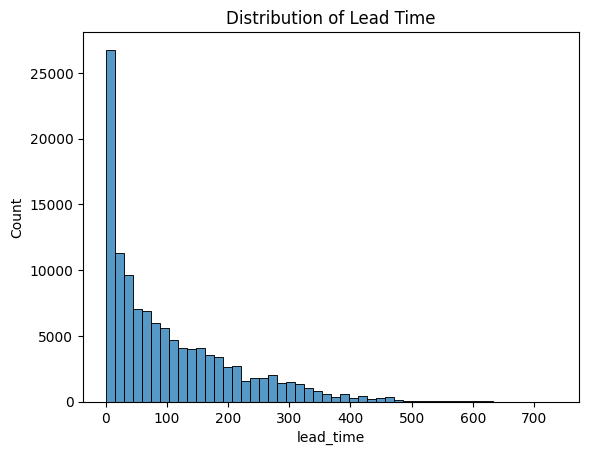

In [8]:
sns.histplot(df["lead_time"], bins=50)
plt.title("Distribution of Lead Time")

#### Country Distribuition

Text(0.5, 1.0, 'Country Distribuition')

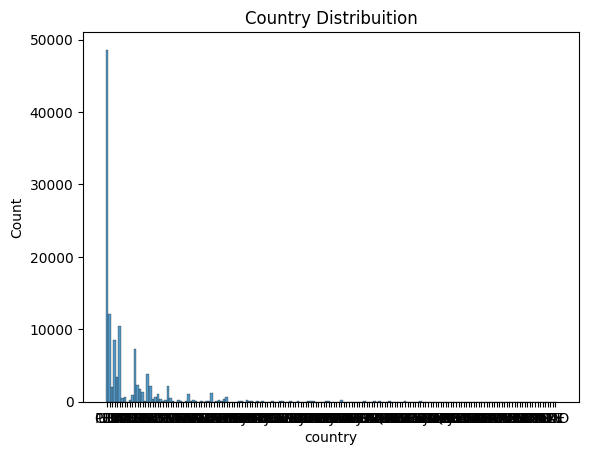

In [9]:
sns.histplot(df["country"], bins=70)
plt.title("Country Distribuition")

#### Price Fluctuation

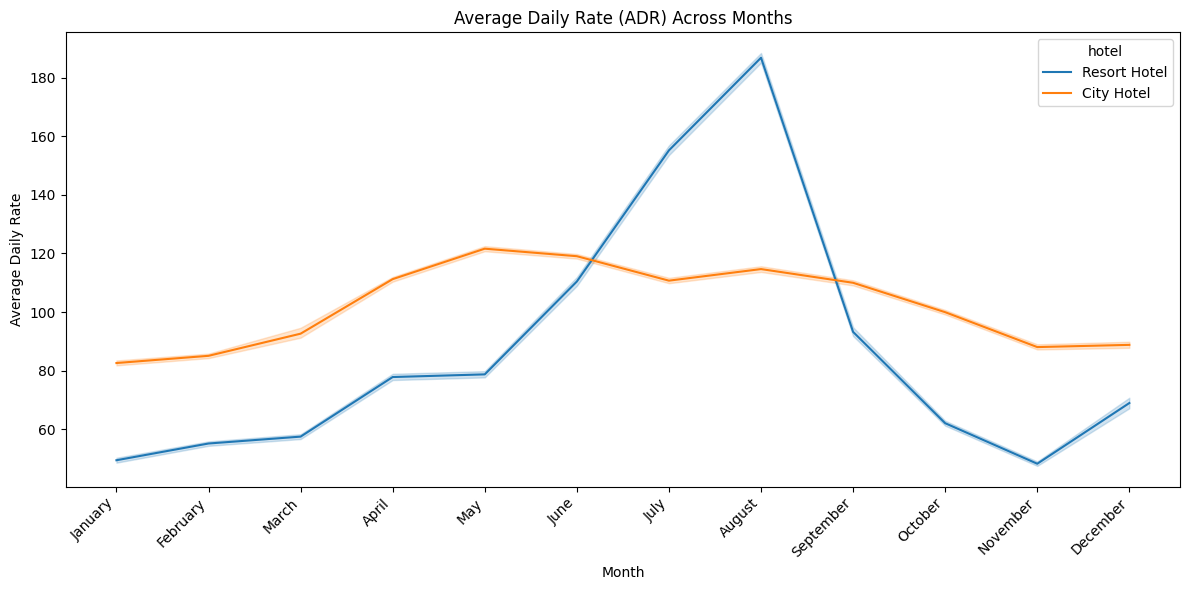

In [10]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# Convert the column to an ordered categorical type
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df)

plt.xticks(rotation=45, ha='right') 
plt.title('Average Daily Rate (ADR) Across Months')
plt.ylabel('Average Daily Rate')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

#### Market Segmentation

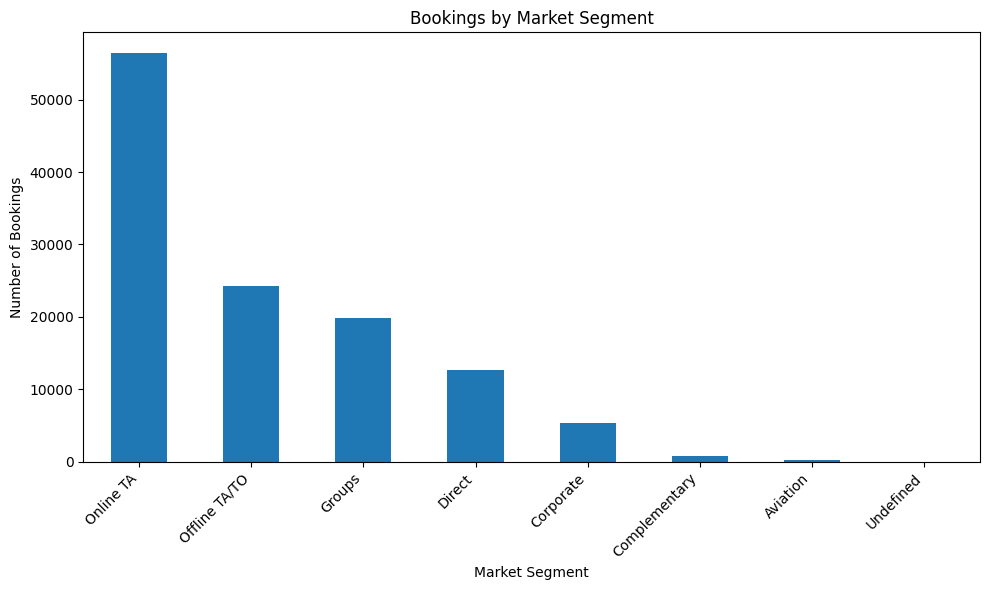

In [11]:
plt.figure(figsize=(10, 6))

market_counts = df['market_segment'].value_counts().plot(kind='bar')

plt.title('Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

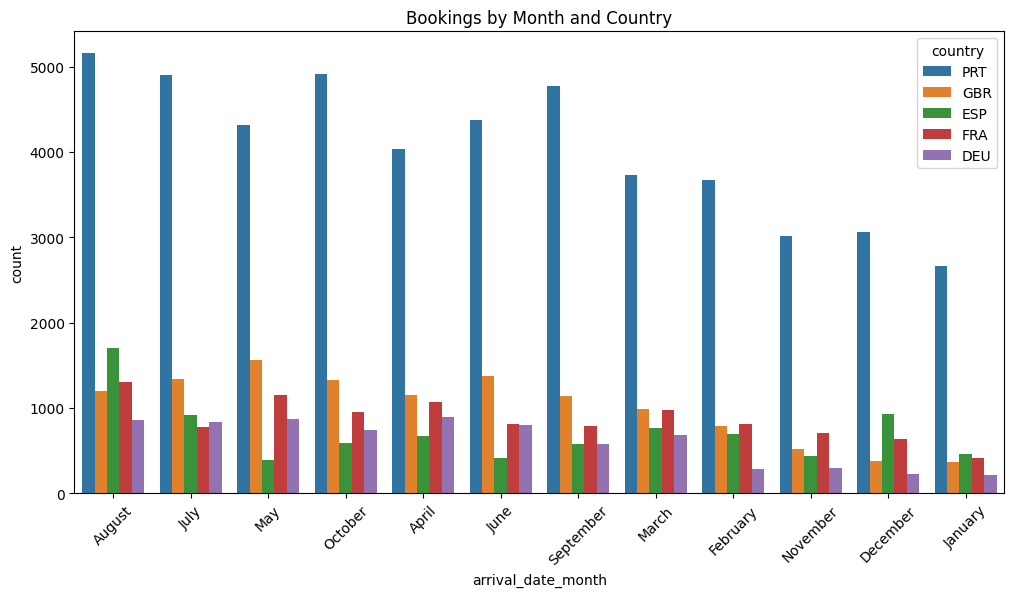

In [12]:
top_countries = df["country"].value_counts().nlargest(5).index

df_top = df[df["country"].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.countplot(data=df_top, x="arrival_date_month", hue="country",
              order=df["arrival_date_month"].value_counts().index)

plt.xticks(rotation=45)
plt.title("Bookings by Month and Country")
plt.show()

Text(0.5, 1.0, 'Lead Time by Country')

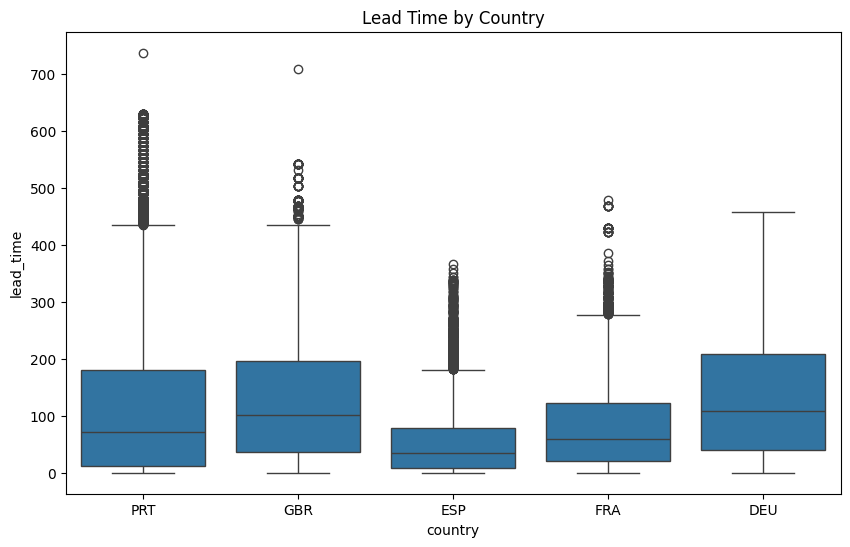

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_top, x="country", y="lead_time")
plt.title("Lead Time by Country")

Text(0.5, 1.0, 'Heatmap: Country vs Month')

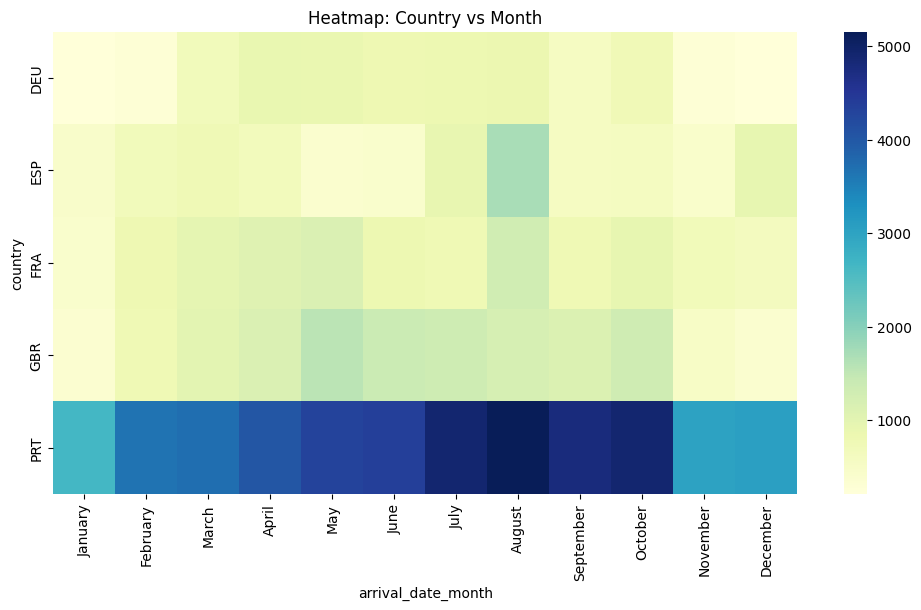

In [14]:
pivot = pd.crosstab(df_top["country"], df_top["arrival_date_month"])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Heatmap: Country vs Month")

#### Categorical Variables Distribuitions

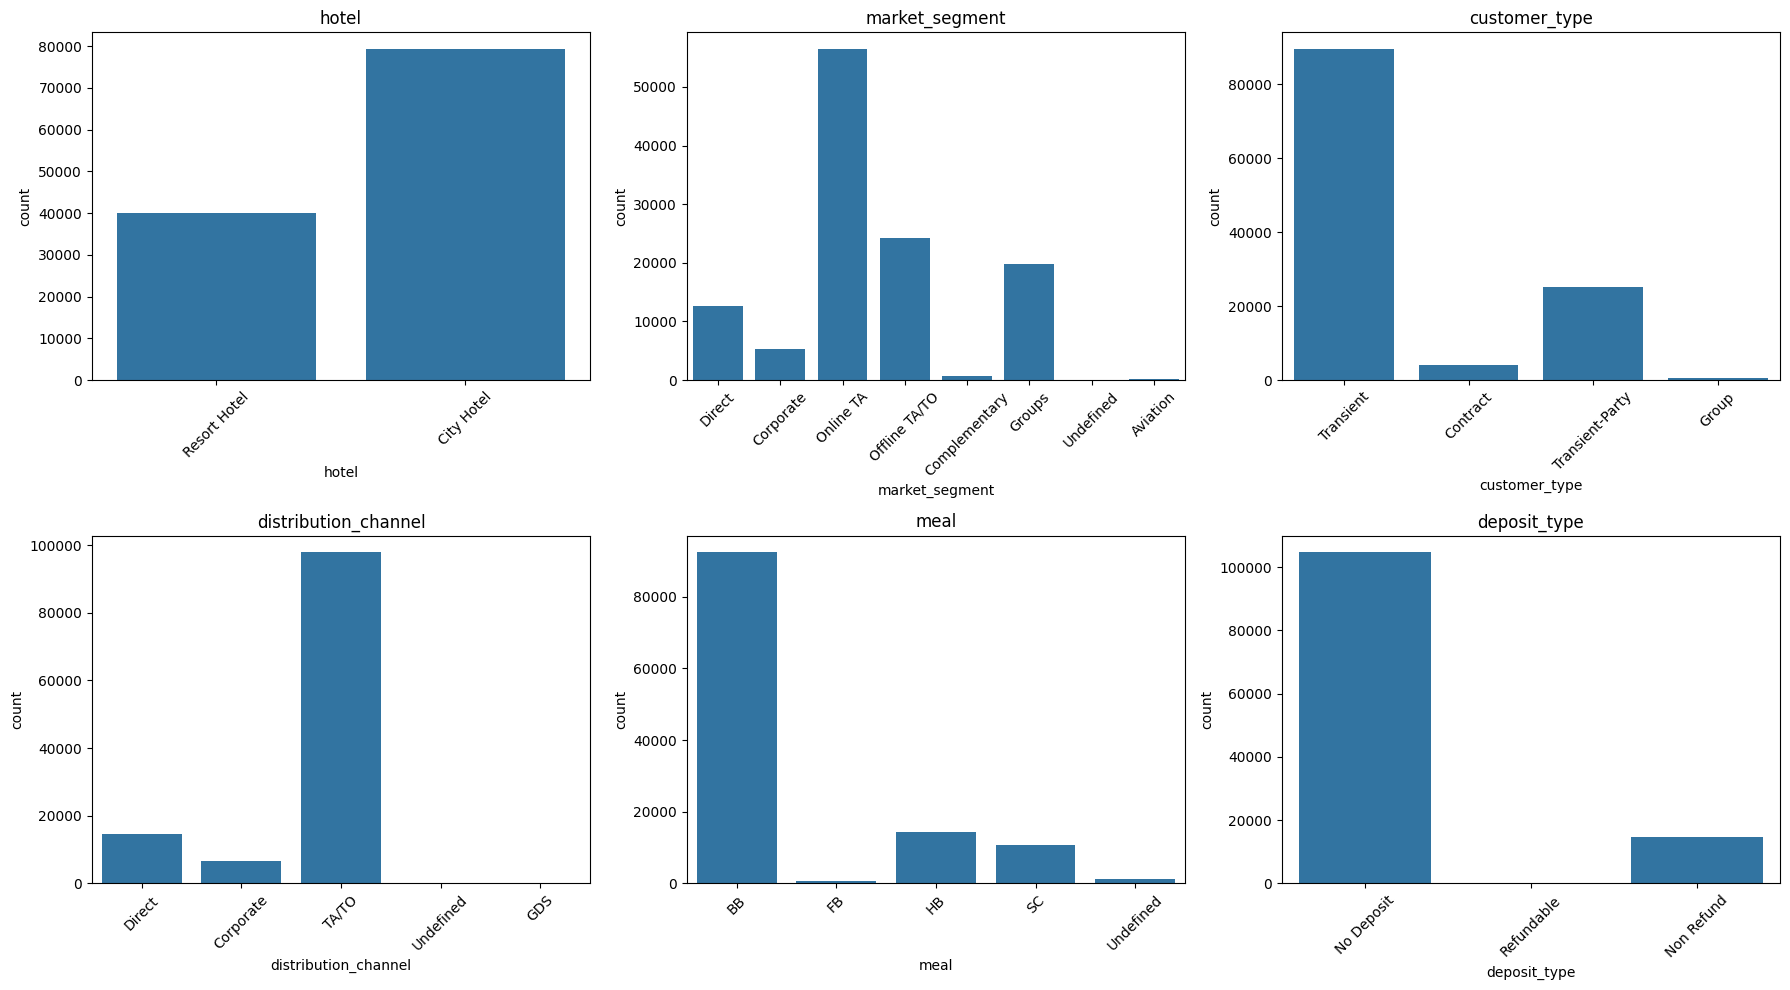

In [15]:
categorical_cols = [
    "hotel",
    "market_segment",
    "customer_type",
    "distribution_channel",
    "meal",
    "deposit_type"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

for col, ax in zip(categorical_cols, axes.flatten()):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Reservations by Month

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'August'),
  Text(1, 0, 'July'),
  Text(2, 0, 'May'),
  Text(3, 0, 'October'),
  Text(4, 0, 'April'),
  Text(5, 0, 'June'),
  Text(6, 0, 'September'),
  Text(7, 0, 'March'),
  Text(8, 0, 'February'),
  Text(9, 0, 'November'),
  Text(10, 0, 'December'),
  Text(11, 0, 'January')])

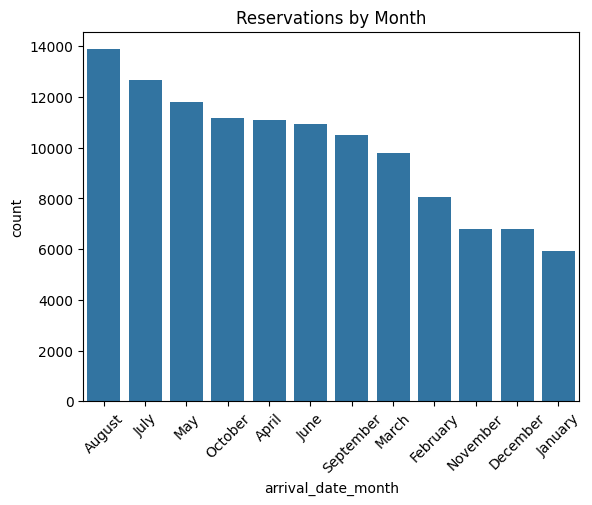

In [16]:
sns.countplot(x="arrival_date_month", data=df,
              order=df["arrival_date_month"].value_counts().index)
plt.title('Reservations by Month')
plt.xticks(rotation=45)

#### Number of Nights

Text(0.5, 1.0, 'Number of Nights')

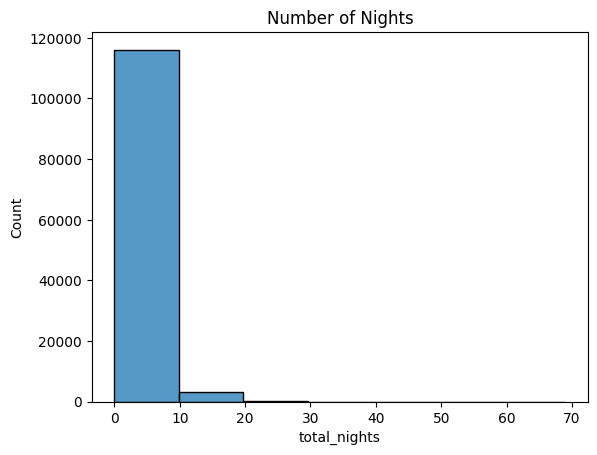

In [17]:
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

sns.histplot(df["total_nights"], bins=7)
plt.title('Number of Nights')

#### Lead time vs hotel

<Axes: xlabel='hotel', ylabel='lead_time'>

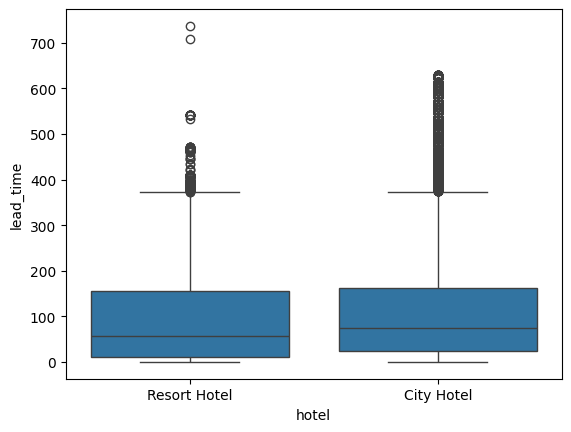

In [18]:
sns.boxplot(x="hotel", y="lead_time", data=df)

#### Cancelations

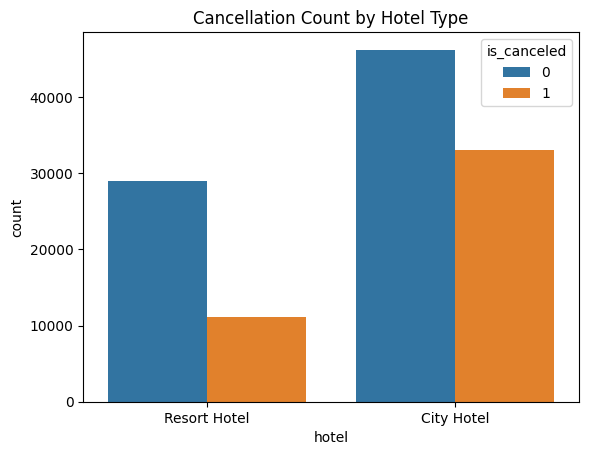

In [19]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellation Count by Hotel Type')
plt.show()

## **Data preprocessing**

#### Delete Variables

In [20]:
# Leakage Control and high cardinality variables
drop_cols = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date",
    "agent",
    "company"
]

df = df.drop(columns=drop_cols)

## **Feature Engineering**

In [21]:
# Arrival Date
date_string = (df['arrival_date_day_of_month'].astype(str) + '-' + df['arrival_date_month'].astype(str) + '-' + df['arrival_date_year'].astype(str))
df['arrival_date'] = pd.to_datetime(date_string, format='%d-%B-%Y')
# df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date']].head()

# Total Nights
df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]

# Total Guests
df["total_guests"] = (df["adults"] + df["children"].fillna(0) + df["babies"]).astype(int)

# Room change to see upgrades and overbooking
df["room_changed"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

# Group rare countries
top_countries = df["country"].value_counts().nlargest(10).index
df["country_grouped"] = df["country"].apply(lambda x: x if x in top_countries else "Other")

df.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,arrival_date,total_guests,room_changed,country_grouped
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,0,2015-07-01,2,0,PRT
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,0,2015-07-01,2,0,PRT
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,1,2015-07-01,1,1,GBR
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,1,2015-07-01,1,0,GBR
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,2,2015-07-01,2,0,GBR


## **Extended Feature Engineering (for Hierarchical Clustering)**

In [22]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "adr",
    "total_nights",
    "lead_time",
    "total_of_special_requests",
]

X = df[cluster_features].copy()

scaler_x = StandardScaler()
X_scaled = pd.DataFrame(scaler_x.fit_transform(X), columns=X.columns)

X_scaled.describe()

,adr,total_nights,lead_time,total_of_special_requests
count,1.193900e+05,1.193900e+05,1.193900e+05,1.193900e+05
mean,-7.617847e-18,1.523569e-17,3.428031e-17,-3.808923e-17
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.141286e+00,-1.340370e+00,-9.733187e-01,-7.206941e-01
25%,-6.439250e-01,-5.583345e-01,-8.048782e-01,-7.206941e-01
50%,-1.435844e-01,-1.673166e-01,-3.276301e-01,-7.206941e-01
75%,4.782547e-01,2.237013e-01,5.239303e-01,5.406659e-01
max,1.048404e+02,2.563986e+01,5.923385e+00,5.586106e+00


In [23]:
from sklearn.preprocessing import StandardScaler

df_cluster = df.copy()

# --- Feature construction ---
df_cluster["total_spend"] = df_cluster["adr"] * df_cluster["total_nights"]

meal_order = {"SC": 0, "BB": 1, "HB": 2, "FB": 3, "Undefined": 0}
df_cluster["meal_encoded"] = df_cluster["meal"].map(meal_order).fillna(0).astype(int)

deposit_order = {"No Deposit": 0, "Refundable": 1, "Non Refund": 2}
df_cluster["deposit_encoded"] = df_cluster["deposit_type"].map(deposit_order).fillna(0).astype(int)

# Lead time → 3 equal-population quantile ranks (0=last-minute, 1=mid, 2=early planner)
df_cluster["lead_time_rank"] = pd.qcut(df_cluster["lead_time"], q=3, labels=[0, 1, 2]).astype(int)

# Log-transform adr (clip the 1 negative value to 0 first)
df_cluster["adr_log"] = np.log1p(df_cluster["adr"].clip(lower=0))

# One-hot encode hotel (in-memory only)
df_cluster = pd.get_dummies(df_cluster, columns=["hotel"], drop_first=False)

# --- Feature groups ---
std_features = ["adr_log", "total_spend", "total_nights"]   # continuous → StandardScaler
raw_features = ["deposit_encoded", "total_of_special_requests",
                "required_car_parking_spaces", "meal_encoded",
                "lead_time_rank", "hotel_Resort Hotel"]      # ordinal/binary → no scaling

std_features = [f for f in std_features if f in df_cluster.columns]
raw_features = [f for f in raw_features if f in df_cluster.columns]

# --- Scaling ---
scaler_std = StandardScaler()

X_std = scaler_std.fit_transform(df_cluster[std_features])
X_raw = df_cluster[raw_features].values.astype(float)

X_v2_scaled = np.hstack([X_std, X_raw])
cluster_features_v2 = std_features + raw_features

# Lower weight for meal_encoded — coarse ordinal proxy
meal_idx = cluster_features_v2.index("meal_encoded")
X_v2_scaled[:, meal_idx] *= 0.5

print(f"Feature matrix shape: {X_v2_scaled.shape}")
print(f"Features: {cluster_features_v2}")
print("\nlead_time quantile boundaries:")
print(pd.qcut(df_cluster["lead_time"], q=3).value_counts().sort_index())

Feature matrix shape: (119390, 9)
Features: ['adr_log', 'total_spend', 'total_nights', 'deposit_encoded', 'total_of_special_requests', 'required_car_parking_spaces', 'meal_encoded', 'lead_time_rank', 'hotel_Resort Hotel']

lead_time quantile boundaries:
lead_time
(-0.001, 32.0]    40081
(32.0, 124.0]     39748
(124.0, 737.0]    39561
Name: count, dtype: int64


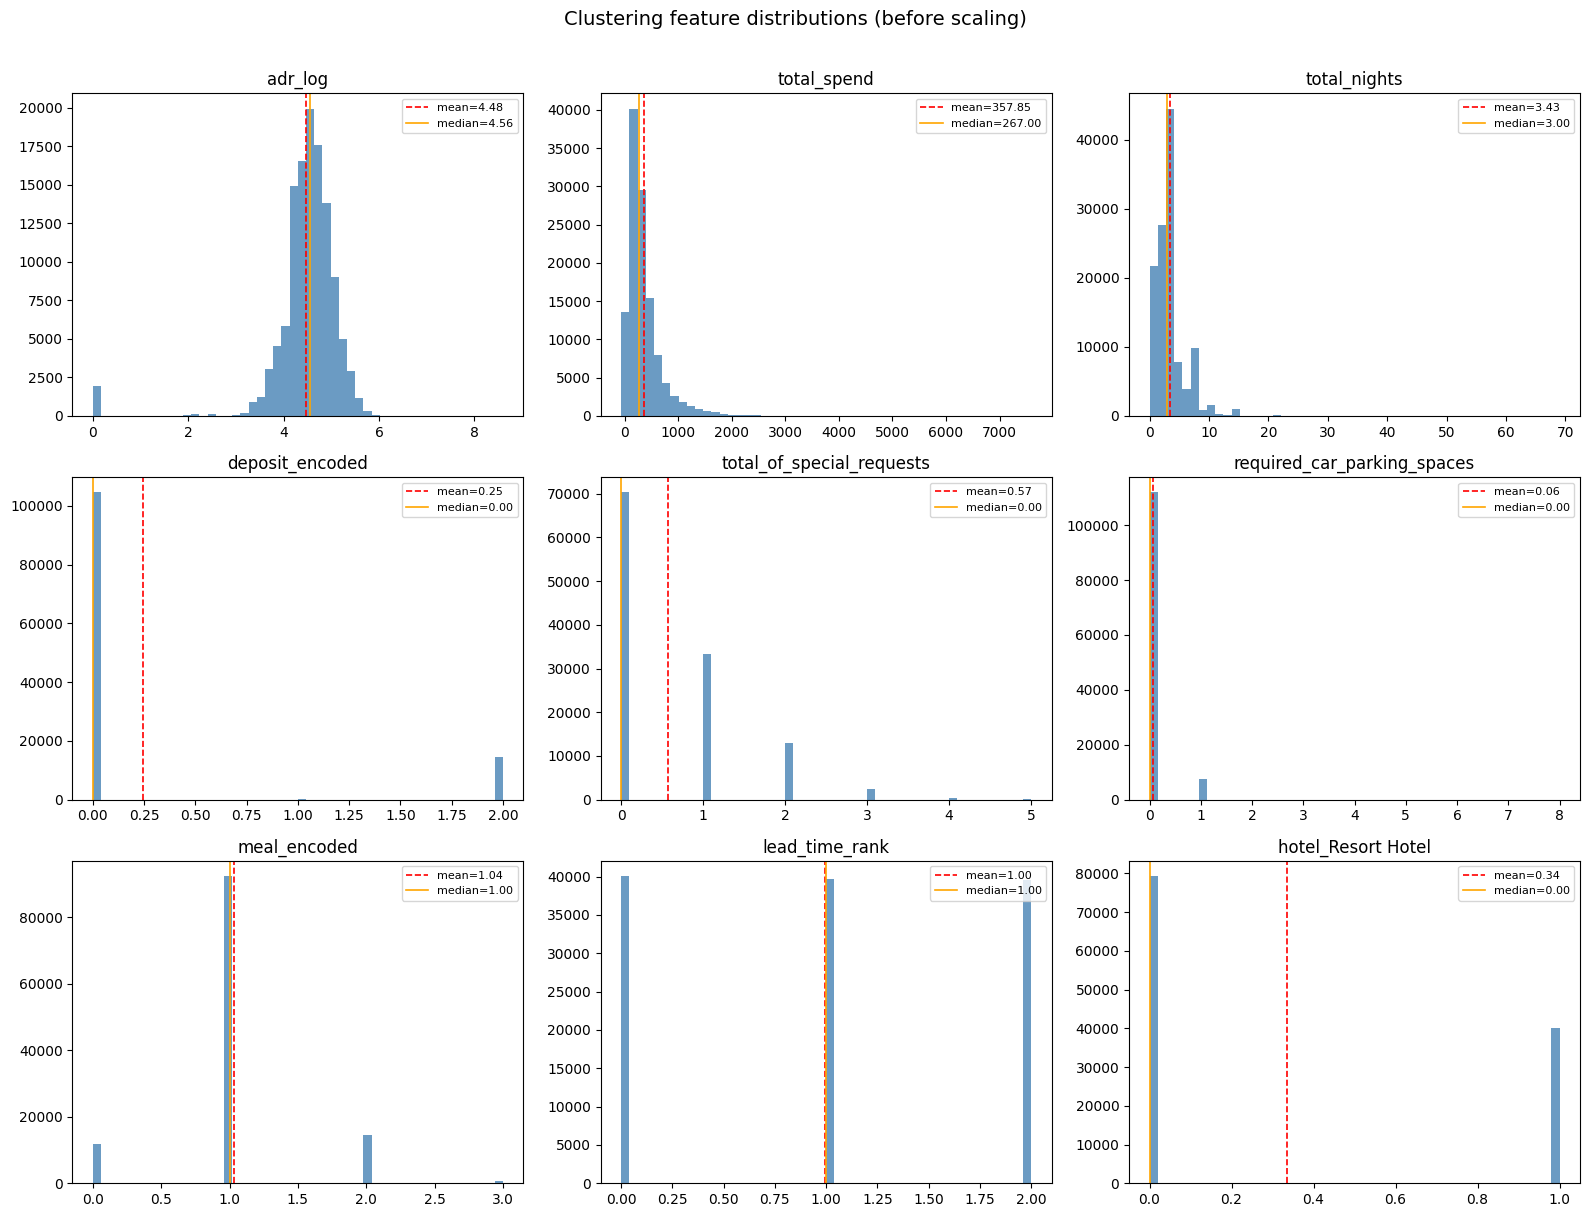

In [24]:
n_cols = 3
n_rows = -(-len(cluster_features_v2) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cluster_features_v2):
    ax = axes[i]
    data = df_cluster[col].astype(float)
    ax.hist(data, bins=50, color="steelblue", alpha=0.8, edgecolor="none")
    ax.axvline(data.mean(),   color="red",    linestyle="--", linewidth=1.2, label=f"mean={data.mean():.2f}")
    ax.axvline(data.median(), color="orange", linestyle="-",  linewidth=1.2, label=f"median={data.median():.2f}")
    ax.set_title(col)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Clustering feature distributions (before scaling)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## **KMeans Clustering**

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from datetime import datetime

k_values = range(2, 11)

results_kmeans = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_v2_scaled)

    silhouette = silhouette_score(X_v2_scaled, labels, sample_size=30000, random_state=42)
    ch_score = calinski_harabasz_score(X_v2_scaled, labels)
    db_score = davies_bouldin_score(X_v2_scaled, labels)

    results_kmeans.append({
        "date/run_id": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": "kmeans",
        "parameters": f"k={k}, n_init=10, max_iter=300",
        "seed": 42,                                    
        "silhouette": silhouette,
        "calinski": ch_score,
        "davies": db_score,
        "diagnostics": "OK",                          
        "notes": "Baseline with StandardScaler" 
    })

results_kmeans = pd.DataFrame(results_kmeans)
results_kmeans

,date/run_id,model,parameters,seed,silhouette,calinski,davies,diagnostics,notes
0,2026-04-27 17:04:26,kmeans,"k=2, n_init=10, max_iter=300",42,0.319661,34217.946127,1.389137,OK,Baseline with StandardScaler
1,2026-04-27 17:04:48,kmeans,"k=3, n_init=10, max_iter=300",42,0.350827,31810.190104,1.071302,OK,Baseline with StandardScaler
2,2026-04-27 17:05:14,kmeans,"k=4, n_init=10, max_iter=300",42,0.292483,32572.499641,1.027773,OK,Baseline with StandardScaler
3,2026-04-27 17:05:41,kmeans,"k=5, n_init=10, max_iter=300",42,0.250211,33387.635958,1.264815,OK,Baseline with StandardScaler
4,2026-04-27 17:06:04,kmeans,"k=6, n_init=10, max_iter=300",42,0.251800,33283.780787,1.204002,OK,Baseline with StandardScaler
5,2026-04-27 17:06:31,kmeans,"k=7, n_init=10, max_iter=300",42,0.254021,32836.000468,1.203418,OK,Baseline with StandardScaler
6,2026-04-27 17:06:59,kmeans,"k=8, n_init=10, max_iter=300",42,0.265577,31408.366549,1.239527,OK,Baseline with StandardScaler
7,2026-04-27 17:07:28,kmeans,"k=9, n_init=10, max_iter=300",42,0.260694,30595.370760,1.229663,OK,Baseline with StandardScaler
8,2026-04-27 17:07:56,kmeans,"k=10, n_init=10, max_iter=300",42,0.250966,29571.831253,1.244653,OK,Baseline with StandardScaler


## **iK-means (Intelligent K-means)**

In [26]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from numpy.typing import NDArray
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

FloatArray = NDArray[np.float64]

@dataclass(frozen=True)
class APCluster:
    indices: list[int]
    centroid_raw: FloatArray
    centroid_std: FloatArray
    size: int
    scatter_pct: float

def compute_feature_statistics(
    X: FloatArray,
    use_unit_ranges: bool = False,
) -> tuple[FloatArray, FloatArray, float]:
    """Calcula a média, a escala (range) e a dispersão total D (Algorithm 1 - Steps 1-5)."""
    mean = np.mean(X, axis=0)

    if use_unit_ranges:
        scales = np.ones(X.shape[1], dtype=np.float64)
    else:
        scales = np.max(X, axis=0) - np.min(X, axis=0)
        scales[scales == 0] = 1.0  

    Y = (X - mean) / scales
    D = np.sum(np.linalg.norm(Y, axis=1)**2)  

    return mean, scales, D

def normalized_squared_distances(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    reference: FloatArray,
) -> FloatArray:
    """Calcula a distância quadrada normalizada entre um subset de X e um ponto de referência."""
    subset = X[indices]
    diff = (subset - reference) / scales
    return np.sum(diff**2, axis=1)

def cluster_centroid(
    X: FloatArray,
    indices: list[int],
) -> FloatArray:
    """Calcula o centroide (média) das linhas de X indexadas por indices."""
    return np.mean(X[indices], axis=0)

def extract_anomalous_cluster(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    mean: FloatArray,
    initial_centroid: FloatArray,
    seed_index: int,
    tol: float = 1e-12,
    max_iter: int = 10_000,
) -> tuple[list[int], FloatArray]:
    """Extrai UM cluster anómalo (Algorithm 2)."""
    c = initial_centroid.copy()
    S_prev = set()

    for _ in range(max_iter):
        dist_to_c = normalized_squared_distances(X, indices, scales, c)
        dist_to_mean = normalized_squared_distances(X, indices, scales, mean)

        # Atribuição: strictly closer to c than to mean (Step 4)
        S_bool = dist_to_c < dist_to_mean
        S = [indices[i] for i, is_closer in enumerate(S_bool) if is_closer]

        if not S:
            S = [seed_index]  # Numerical safeguard

        c_new = cluster_centroid(X, S)

        if set(S) == S_prev:
            return sorted(S), c_new
        if np.linalg.norm(c_new - c) <= tol:
            return sorted(S), c_new

        c = c_new
        S_prev = set(S)

    return sorted(S), c

def ikmeans_initialize(
    X: FloatArray,
    min_cluster_size: int,
    tol: float = 1e-12,
    max_iter: int = 10_000,
    use_unit_ranges: bool = False,
) -> tuple[list[APCluster], FloatArray]:
    """Procedimento principal do iK-means (Algorithm 1)."""
    X = np.asarray(X, dtype=np.float64)
    n, d = X.shape

    mean, scales, D = compute_feature_statistics(X, use_unit_ranges)

    remains = list(range(n))
    ap_clusters = []

    while remains:
        dists_to_mean = normalized_squared_distances(X, remains, scales, mean)
        farthest_idx_in_remains = np.argmax(dists_to_mean)
        q = remains[farthest_idx_in_remains]
        seed = X[q].copy()

        S, c = extract_anomalous_cluster(X, remains, scales, mean, seed, q, tol, max_iter)

        z = (c - mean) / scales
        if D > 0:
            scatter_pct = 100.0 * len(S) * (np.linalg.norm(z)**2) / D
        else:
            scatter_pct = 0.0

        ap_clusters.append(APCluster(
            indices=S, centroid_raw=c, centroid_std=z, size=len(S), scatter_pct=scatter_pct
        ))

        remains = [i for i in remains if i not in set(S)]

    retained = [record for record in ap_clusters if record.size >= min_cluster_size]

    if not retained:
        raise ValueError("No anomalous cluster satisfies the minimum size.")

    init_centroids = np.vstack([record.centroid_std for record in retained])

    return ap_clusters, init_centroids

In [ ]:
min_cluster_size = 1000  

ap_clusters, init_centroids = ikmeans_initialize(
    X_v2_scaled,
    min_cluster_size=min_cluster_size,
    tol=1e-12,
    max_iter=10000,
    use_unit_ranges=True
)

k_ikmeans = init_centroids.shape[0]

kmeans_ik = KMeans(
    n_clusters=k_ikmeans,
    init=init_centroids,  
    n_init=1,            
    random_state=42
)
ik_labels = kmeans_ik.fit_predict(X_v2_scaled)

ik_silhouette = silhouette_score(X_v2_scaled, ik_labels, sample_size=10000, random_state=42)
ik_calinski = calinski_harabasz_score(X_v2_scaled, ik_labels)
ik_davies = davies_bouldin_score(X_v2_scaled, ik_labels)

print(f"iK-means final: k={k_ikmeans}, silhouette={ik_silhouette:.4f}")

for i, cluster in enumerate(ap_clusters):
    print(f"Cluster {i+1}: {cluster.size} pontos, {cluster.scatter_pct:.1f}% da dispersão total")

results_ikmeans = pd.DataFrame([{        
    "date/run_id": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "ikmeans",
    "k": k_ikmeans,
    "parameters": f"k={k_ikmeans} (auto), min_cluster_size={min_cluster_size}",
    "seed": 42,
    "silhouette": ik_silhouette,
    "calinski": ik_calinski,
    "davies": ik_davies,
    "diagnostics": "OK",
    "notes": f"iK-means: {len(ap_clusters)} clusters anômalos extraídos, {k_ikmeans} retidos"
}])

results_ikmeans

iK-means encontrou 10 clusters anômalos válidos
iK-means final: k=10, silhouette=0.2380
Cluster 1: 13653 pontos, 19.0% da dispersão total
Cluster 2: 2 pontos, 0.0% da dispersão total
Cluster 3: 2147 pontos, 13.0% da dispersão total
Cluster 4: 25323 pontos, 6.6% da dispersão total
Cluster 5: 36687 pontos, 7.8% da dispersão total
Cluster 6: 15170 pontos, 2.8% da dispersão total
Cluster 7: 13470 pontos, 1.9% da dispersão total
Cluster 8: 2289 pontos, 0.6% da dispersão total
Cluster 9: 3609 pontos, 0.4% da dispersão total
Cluster 10: 63 pontos, 0.0% da dispersão total
Cluster 11: 4834 pontos, 0.4% da dispersão total
Cluster 12: 100 pontos, 0.0% da dispersão total
Cluster 13: 245 pontos, 0.0% da dispersão total
Cluster 14: 1694 pontos, 0.1% da dispersão total
Cluster 15: 104 pontos, 0.0% da dispersão total


,date/run_id,model,k,parameters,seed,silhouette,calinski,davies,diagnostics,notes
0,2026-04-27 17:16:10,ikmeans,10,"k=10 (auto), min_cluster_size=1000",42,0.238012,29223.343943,1.377143,OK,"iK-means: 15 clusters anômalos extraídos, 10 r..."


## **Third Clustering Algorithm — Agglomerative Hierarchical (Ward)**

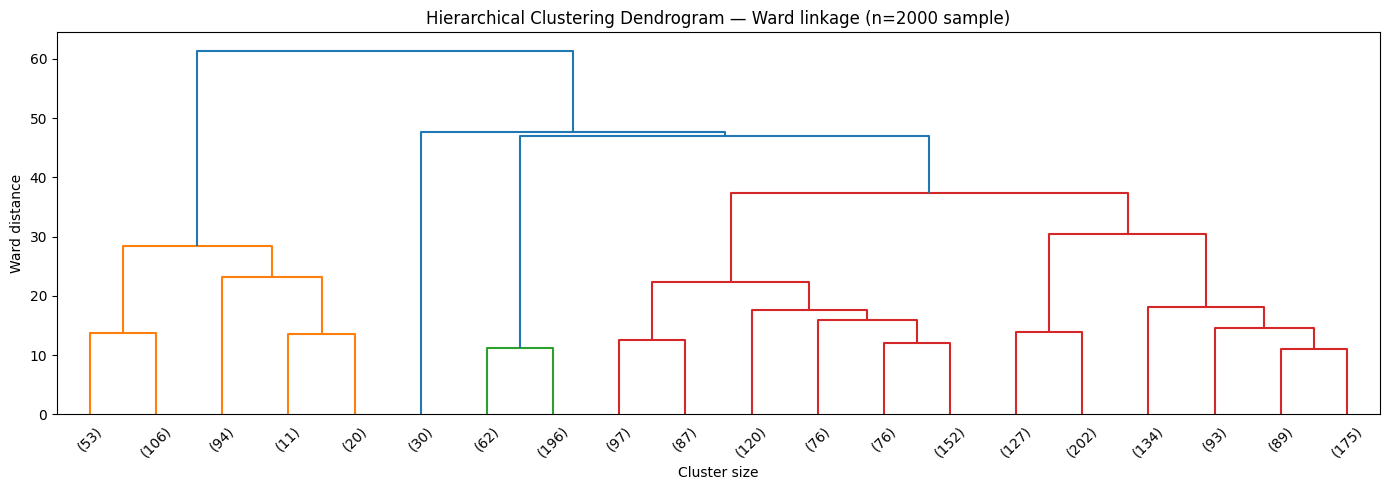

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogram on a 2000-row sample (full 119k is too expensive to plot)
sample_idx = np.random.RandomState(42).choice(len(X_v2_scaled), size=2000, replace=False)
X_sample = X_v2_scaled[sample_idx]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode="lastp", p=20, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram — Ward linkage (n=2000 sample)")
plt.xlabel("Cluster size")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering

# Subsample n=30000 (reproducible seed) — Ward on full 119k is prohibitively slow
subsample_idx = np.random.RandomState(42).choice(len(X_v2_scaled), size=30000, replace=False)
X_hier = X_v2_scaled[subsample_idx]

k_values = range(2, 9)
results_hier = []

for k in k_values:
    hier = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hier.fit_predict(X_hier)

    results_hier.append({
        "date/run_id": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": "hierarchical_ward",
        "parameters": f"k={k}, linkage='ward'",   
        "seed": 42,
        "silhouette": silhouette_score(X_hier, labels, sample_size=15000, random_state=42),
        "calinski": calinski_harabasz_score(X_hier, labels),
        "davies": davies_bouldin_score(X_hier, labels),
        "diagnostics": "OK",                     
        "notes": "Hierarchical com StandardScaler" 
    })

results_hier = pd.DataFrame(results_hier)
results_hier

,date/run_id,model,parameters,seed,silhouette,calinski,davies,diagnostics,notes
0,2026-04-27 17:17:22,hierarchical_ward,"k=2, linkage='ward'",42,0.444086,6876.456138,1.059447,OK,Hierarchical com StandardScaler
1,2026-04-27 17:18:37,hierarchical_ward,"k=3, linkage='ward'",42,0.462285,6488.387037,0.857759,OK,Hierarchical com StandardScaler
2,2026-04-27 17:19:51,hierarchical_ward,"k=4, linkage='ward'",42,0.273777,6985.757832,0.938892,OK,Hierarchical com StandardScaler
3,2026-04-27 17:21:18,hierarchical_ward,"k=5, linkage='ward'",42,0.210512,7111.317032,1.272241,OK,Hierarchical com StandardScaler
4,2026-04-27 17:22:41,hierarchical_ward,"k=6, linkage='ward'",42,0.211949,7064.660097,1.425056,OK,Hierarchical com StandardScaler
5,2026-04-27 17:23:43,hierarchical_ward,"k=7, linkage='ward'",42,0.227565,6984.889370,1.379479,OK,Hierarchical com StandardScaler
6,2026-04-27 17:24:56,hierarchical_ward,"k=8, linkage='ward'",42,0.226701,6626.121715,1.312470,OK,Hierarchical com StandardScaler


## **Evaluations Metrics**

In [30]:
results_all = pd.concat([results_kmeans, results_ikmeans, results_hier], ignore_index=True)
results_all.to_csv("experiments.csv", index=False)
results_all

,date/run_id,model,parameters,seed,silhouette,calinski,davies,diagnostics,notes,k
0,2026-04-27 17:04:26,kmeans,"k=2, n_init=10, max_iter=300",42,0.319661,34217.946127,1.389137,OK,Baseline with StandardScaler,NaN
1,2026-04-27 17:04:48,kmeans,"k=3, n_init=10, max_iter=300",42,0.350827,31810.190104,1.071302,OK,Baseline with StandardScaler,NaN
2,2026-04-27 17:05:14,kmeans,"k=4, n_init=10, max_iter=300",42,0.292483,32572.499641,1.027773,OK,Baseline with StandardScaler,NaN
3,2026-04-27 17:05:41,kmeans,"k=5, n_init=10, max_iter=300",42,0.250211,33387.635958,1.264815,OK,Baseline with StandardScaler,NaN
4,2026-04-27 17:06:04,kmeans,"k=6, n_init=10, max_iter=300",42,0.251800,33283.780787,1.204002,OK,Baseline with StandardScaler,NaN
5,2026-04-27 17:06:31,kmeans,"k=7, n_init=10, max_iter=300",42,0.254021,32836.000468,1.203418,OK,Baseline with StandardScaler,NaN
6,2026-04-27 17:06:59,kmeans,"k=8, n_init=10, max_iter=300",42,0.265577,31408.366549,1.239527,OK,Baseline with StandardScaler,NaN
7,2026-04-27 17:07:28,kmeans,"k=9, n_init=10, max_iter=300",42,0.260694,30595.370760,1.229663,OK,Baseline with StandardScaler,NaN
8,2026-04-27 17:07:56,kmeans,"k=10, n_init=10, max_iter=300",42,0.250966,29571.831253,1.244653,OK,Baseline with StandardScaler,NaN
9,2026-04-27 17:16:10,ikmeans,"k=10 (auto), min_cluster_size=1000",42,0.238012,29223.343943,1.377143,OK,"iK-means: 15 clusters anômalos extraídos, 10 r...",10.0


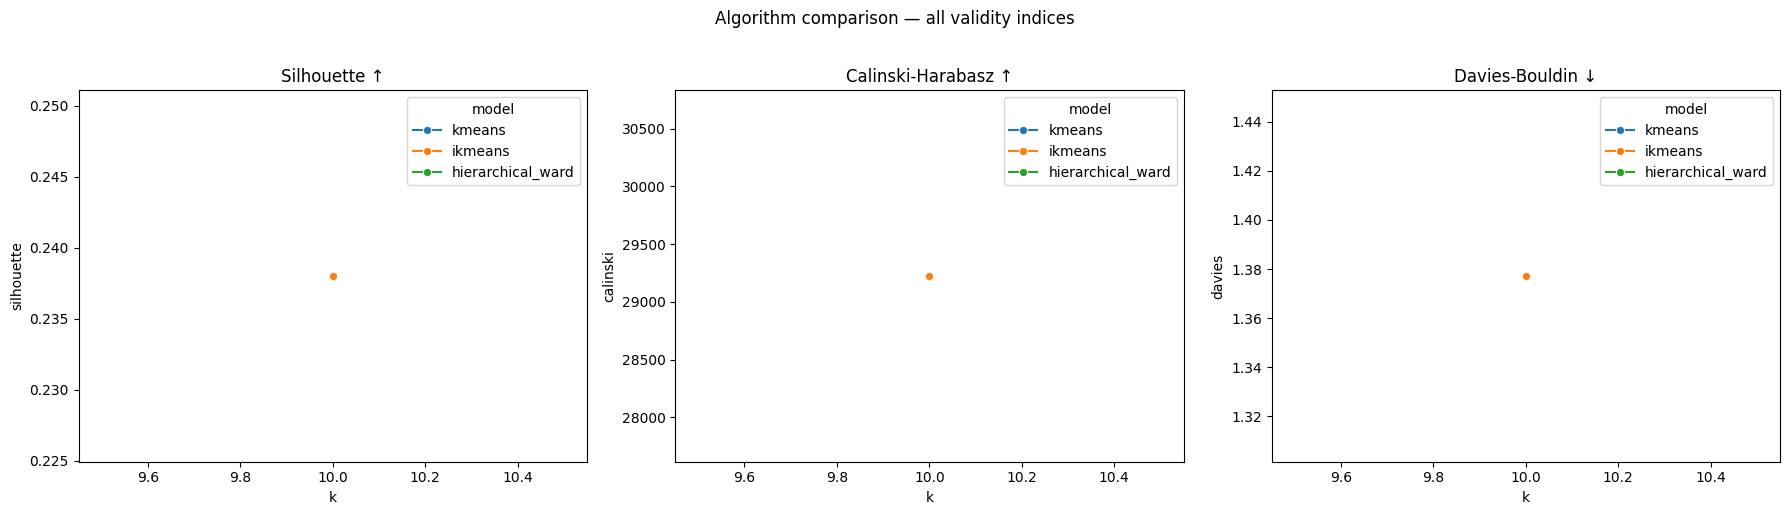

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes, ["silhouette", "calinski", "davies"],
                              ["Silhouette ↑", "Calinski-Harabasz ↑", "Davies-Bouldin ↓"]):
    sns.lineplot(data=results_all, x="k", y=metric, hue="model", marker="o", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("k")

plt.suptitle("Algorithm comparison — all validity indices", y=1.02)
plt.tight_layout()
plt.show()

## **Stability Analysis**

In [32]:
from sklearn.metrics import adjusted_rand_score

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

stability_scores = []

for k in [2, 3, 4, 5]:
    labels_list = []

    for seed in seeds:
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = kmeans.fit_predict(X_v2_scaled)
        labels_list.append(labels)

    ari_scores = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            ari = adjusted_rand_score(labels_list[i], labels_list[j])
            ari_scores.append(ari)

    stability_scores.append({
        "k": k,
        "mean_ari": np.mean(ari_scores),
        "std_ari": np.std(ari_scores)
    })

stability_df = pd.DataFrame(stability_scores)
stability_df

,k,mean_ari,std_ari
0,2,0.997328,0.002489
1,3,0.860113,0.268853
2,4,0.684351,0.223010
3,5,0.990109,0.004512


## **Sensitivity Analysis**

In [33]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

X_v2_raw = df_cluster[cluster_features_v2].copy()

# Compare three uniform scalers vs the mixed pipeline used in the main analysis
scalers = {
    "standard (uniform)": StandardScaler(),
    "robust (uniform)":   RobustScaler(),
    "minmax (uniform)":   MinMaxScaler(),
}

sensitivity_results = []

for name, scaler in scalers.items():
    X_sens = scaler.fit_transform(X_v2_raw)
    meal_idx = cluster_features_v2.index("meal_encoded")
    X_sens[:, meal_idx] *= 0.5

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sens)

    sensitivity_results.append({
        "scaler": name,
        "k": 4,
        "silhouette": silhouette_score(X_sens, labels, sample_size=10000, random_state=42),
        "calinski":   calinski_harabasz_score(X_sens, labels),
        "davies":     davies_bouldin_score(X_sens, labels),
    })

pd.DataFrame(sensitivity_results)

,scaler,k,silhouette,calinski,davies
0,standard (uniform),4,0.316703,27141.328249,1.244783
1,robust (uniform),4,0.237577,40926.261595,1.231717
2,minmax (uniform),4,0.508739,112617.868660,0.699067


## **Cluster Interpretation**

In [34]:
best_k = 3
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_v2_scaled)

df["cluster"] = labels

# Numeric profile
cluster_profile_num = df.groupby("cluster").mean(numeric_only=True)

# Categorical profile
cat_cols = df.select_dtypes(include=["object", "string"]).columns
cluster_profile_cat = df.groupby("cluster")[cat_cols].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

print("Numerical profile:")
display(cluster_profile_num)

print("Categorical profile:")
display(cluster_profile_cat)

Numerical profile:


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,room_changed
cluster,,,,,,,,,,,,,,,,,,,,
0,99.812127,2016.142756,26.811086,15.821907,0.683264,1.932772,1.830332,0.076645,0.005843,0.032098,0.101107,0.148213,0.193143,2.733953,97.485771,0.059875,0.517294,2.616037,1.912818,0.131956
1,129.470985,2016.240560,28.626078,15.717249,2.084806,5.195446,2.003441,0.228974,0.017018,0.008391,0.023193,0.020883,0.320982,0.564748,131.815240,0.074718,0.815820,7.280253,2.249423,0.065196
2,40.645370,2015.944907,28.557870,15.541667,0.424074,1.259722,1.571296,0.086574,0.012500,0.254630,0.093056,0.784259,0.484259,1.220370,0.522991,0.060185,0.574074,1.683796,1.670370,0.400000


Categorical profile:


,hotel,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,country_grouped
cluster,,,,,,,,,,
0,City Hotel,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,PRT
1,Resort Hotel,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,PRT
2,City Hotel,BB,PRT,Complementary,TA/TO,A,A,No Deposit,Transient,PRT
